# GASP Noise Robustness Analysis (v0)

This notebook evaluates the robustness of different GASP methods to noise across various tissue types.

## Methods Tested
1. **Standard GASP** with different polynomial bases:
   - Linear
   - Affine
   - Quadratic
   - Quadratic with cross-terms

## Tissue Types
- Gray Matter, White Matter, CSF/Water, Muscle, Fat, Liver

In [4]:
import sys
sys.path.insert(0, '../../')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import pandas as pd
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# GASP imports
from gasp import responses, sampling
from gasp.gasp import train_gasp, run_gasp
from gasp.simulation import SSFPParams, simulate_ssfp_simple

# Set random seed for reproducibility
np.random.seed(42)

# Set default plot style
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Imports successful!")

Imports successful!


## 1. Configuration Parameters

In [5]:
# Simulation parameters
WIDTH = 256  # Number of off-resonance points
HEIGHT = 1   # 1D simulation
NPCS = 16    # Number of phase cycles
TRS_BASE = [5e-3, 10e-3, 20e-3]  # Base TR values
GRADIENT = 2 * np.pi
ALPHA = np.deg2rad(30)  # Flip angle

# Target response parameters
BANDWIDTH = 0.25  # Passband width
SHIFT = 0.0      # Center frequency shift

# Noise levels to test (relative to signal)
NOISE_SIGMAS = np.array([0.0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1])

# Monte Carlo iterations for statistical robustness
N_MONTE_CARLO = 50

# GASP methods to compare
GASP_METHODS = ['linear', 'affine', 'quad', 'quad-cross']

# Tissue types with their T1/T2 parameters (in seconds)
TISSUES = {
    'Gray Matter': {'T1': 0.9, 'T2': 0.1},
    'White Matter': {'T1': 0.6, 'T2': 0.08},
    'Water/CSF': {'T1': 4.0, 'T2': 2.0},
    'Muscle': {'T1': 0.9, 'T2': 0.05},
    'Fat': {'T1': 0.25, 'T2': 0.07},
    'Liver': {'T1': 0.5, 'T2': 0.04},
}

print(f"Testing {len(NOISE_SIGMAS)} noise levels: {NOISE_SIGMAS}")
print(f"Testing {len(GASP_METHODS)} GASP methods: {GASP_METHODS}")
print(f"Testing {len(TISSUES)} tissue types: {list(TISSUES.keys())}")
print(f"Monte Carlo iterations: {N_MONTE_CARLO}")

Testing 7 noise levels: [0.    0.001 0.005 0.01  0.02  0.05  0.1  ]
Testing 4 GASP methods: ['linear', 'affine', 'quad', 'quad-cross']
Testing 6 tissue types: ['Gray Matter', 'White Matter', 'Water/CSF', 'Muscle', 'Fat', 'Liver']
Monte Carlo iterations: 50


## 2. Setup Acquisition Parameters and Target Response

Number of acquisition points: 48
Target response shape: (256,)


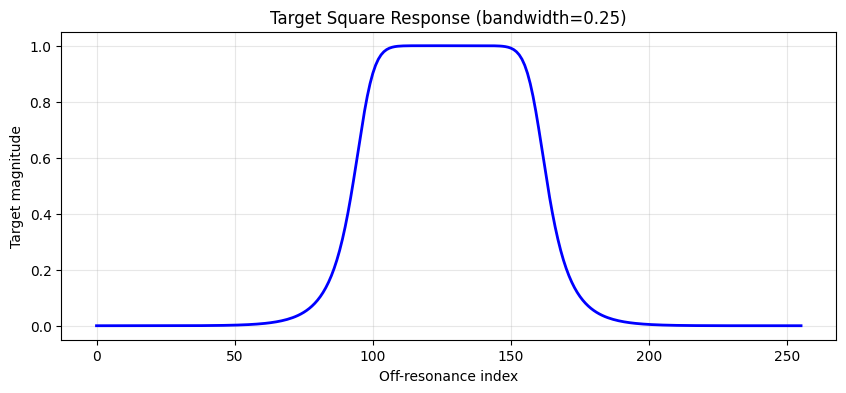

In [ ]:
# Create acquisition parameters
n_points = NPCS * len(TRS_BASE)
TRs, PCs = sampling.grid_TR_sampling(n_points=n_points, TRs=TRS_BASE)
params = SSFPParams(n_points, ALPHA, TRs, PCs)

# Create target response (square passband)
#D = responses.square(WIDTH, bw=BANDWIDTH, shift=SHIFT)
D = responses.bandpass(WIDTH, bw=BANDWIDTH, shift=SHIFT, type='butterworth')

print(f"Number of acquisition points: {n_points}")
print(f"Target response shape: {D.shape}")

# Plot target response
plt.figure(figsize=(10, 4))
plt.plot(D, 'b-', linewidth=2)
plt.xlabel('Off-resonance index')
plt.ylabel('Target magnitude')
plt.title(f'Target Response (bandwidth={BANDWIDTH})')
plt.grid(True, alpha=0.3)
plt.show()

## 3. Helper Functions

In [7]:
def generate_ssfp_signal(T1, T2):
    """
    Generate bSSFP signal for given tissue parameters.
    """
    M = simulate_ssfp_simple(
        width=WIDTH, height=HEIGHT,
        T1=T1, T2=T2,
        params=params,
        minTR=np.min(TRS_BASE),
        gradient=GRADIENT
    )
    return M


def add_complex_noise(signal, sigma):
    """
    Add complex Gaussian noise to signal.
    """
    if sigma == 0:
        return signal.copy()
    
    noise = sigma * (np.random.randn(*signal.shape) + 1j * np.random.randn(*signal.shape))
    return signal + noise


def compute_metrics(output, target):
    """
    Compute performance metrics between GASP output and target response.
    """
    output_mag = np.abs(output).flatten()
    target_flat = target.flatten()
    
    # Root Mean Squared Error
    rmse = np.sqrt(np.mean((output_mag - target_flat) ** 2))
    
    # Correlation coefficient
    if np.std(output_mag) > 1e-10 and np.std(target_flat) > 1e-10:
        corr = np.corrcoef(output_mag, target_flat)[0, 1]
    else:
        corr = 0.0
    
    return {'rmse': rmse, 'correlation': corr}


print("Helper functions defined.")

Helper functions defined.


## 4. Test Single Tissue (Sanity Check)

Signal shape: (1, 256, 48)
Output shape: (1, 256)
Coefficients shape: 49

Clean signal metrics:
  RMSE: 0.0228
  Correlation: 0.9987


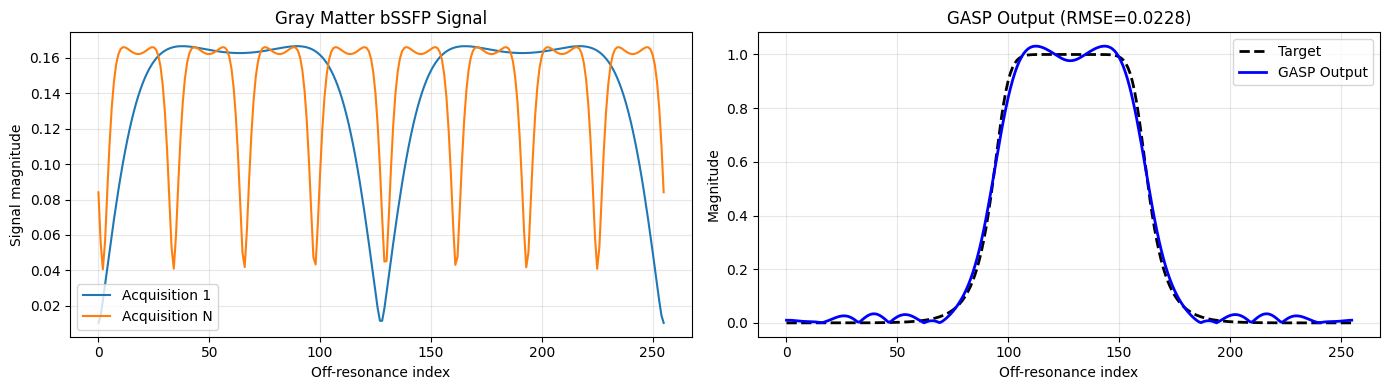

In [8]:
# Test with Gray Matter to verify everything works
test_tissue = 'Gray Matter'
test_params = TISSUES[test_tissue]

# Generate clean signal
M_clean = generate_ssfp_signal(T1=test_params['T1'], T2=test_params['T2'])
print(f"Signal shape: {M_clean.shape}")

# Train GASP
I_clean, A = train_gasp(M_clean, D, method='affine', useL2=True, lam=1e-2)
print(f"Output shape: {I_clean.shape}")
print(f"Coefficients shape: {len(A)}")

# Compute metrics
metrics = compute_metrics(I_clean, D)
print(f"\nClean signal metrics:")
print(f"  RMSE: {metrics['rmse']:.4f}")
print(f"  Correlation: {metrics['correlation']:.4f}")

# Plot result
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot signal magnitude (first acquisition)
axes[0].plot(np.abs(M_clean[0, :, 0]), label='Acquisition 1')
axes[0].plot(np.abs(M_clean[0, :, -1]), label='Acquisition N')
axes[0].set_xlabel('Off-resonance index')
axes[0].set_ylabel('Signal magnitude')
axes[0].set_title(f'{test_tissue} bSSFP Signal')
axes[0].legend()

# Plot GASP output vs target
axes[1].plot(D, 'k--', label='Target', linewidth=2)
axes[1].plot(np.abs(I_clean).flatten(), 'b-', label='GASP Output', linewidth=2)
axes[1].set_xlabel('Off-resonance index')
axes[1].set_ylabel('Magnitude')
axes[1].set_title(f'GASP Output (RMSE={metrics["rmse"]:.4f})')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Run Noise Robustness Analysis

In [9]:
def run_noise_analysis(tissue_name, tissue_params, methods=GASP_METHODS,
                       noise_sigmas=NOISE_SIGMAS, n_mc=N_MONTE_CARLO):
    """
    Run noise robustness analysis for a single tissue type.
    """
    # Generate clean signal
    M_clean = generate_ssfp_signal(T1=tissue_params['T1'], T2=tissue_params['T2'])
    
    results = {method: {'rmse': [], 'correlation': []} for method in methods}
    
    for sigma in noise_sigmas:
        method_metrics = {method: {'rmse': [], 'correlation': []} for method in methods}
        
        for _ in range(n_mc):
            # Add noise
            M_noisy = add_complex_noise(M_clean, sigma)
            
            for method in methods:
                try:
                    # Train GASP on noisy signal
                    I, _ = train_gasp(M_noisy, D, method=method, useL2=True, lam=1e-2)
                    
                    # Compute metrics
                    metrics = compute_metrics(I, D)
                    method_metrics[method]['rmse'].append(metrics['rmse'])
                    method_metrics[method]['correlation'].append(metrics['correlation'])
                    
                except Exception as e:
                    method_metrics[method]['rmse'].append(np.nan)
                    method_metrics[method]['correlation'].append(np.nan)
        
        # Average over Monte Carlo iterations
        for method in methods:
            results[method]['rmse'].append(np.nanmean(method_metrics[method]['rmse']))
            results[method]['correlation'].append(np.nanmean(method_metrics[method]['correlation']))
    
    return results


print("Analysis function defined.")

Analysis function defined.


In [10]:
# Run analysis for all tissues
all_results = {}

print("Running noise robustness analysis for all tissues...")
print("=" * 60)

for tissue_name, tissue_params in tqdm(TISSUES.items(), desc="Tissues"):
    print(f"\nAnalyzing {tissue_name} (T1={tissue_params['T1']}s, T2={tissue_params['T2']}s)...")
    
    results = run_noise_analysis(tissue_name, tissue_params)
    all_results[tissue_name] = results

print("\n" + "=" * 60)
print("Analysis complete!")

Running noise robustness analysis for all tissues...


Tissues:   0%|          | 0/6 [00:00<?, ?it/s]


Analyzing Gray Matter (T1=0.9s, T2=0.1s)...

Analyzing White Matter (T1=0.6s, T2=0.08s)...

Analyzing Water/CSF (T1=4.0s, T2=2.0s)...

Analyzing Muscle (T1=0.9s, T2=0.05s)...


KeyboardInterrupt: 

## 6. Visualize Results by Method

In [ ]:
# Plot RMSE vs Noise Level for each method across all tissues
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = cm.Set2(np.linspace(0, 1, len(TISSUES)))

for idx, method in enumerate(GASP_METHODS):
    ax = axes[idx]
    
    for i, (tissue_name, data) in enumerate(all_results.items()):
        rmse_values = data[method]['rmse']
        ax.semilogy(NOISE_SIGMAS, rmse_values, 'o-', 
                   color=colors[i], label=tissue_name, linewidth=2, markersize=6)
    
    ax.set_xlabel('Noise Sigma', fontsize=12)
    ax.set_ylabel('RMSE (log scale)', fontsize=12)
    ax.set_title(f'Method: {method.upper()}', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('GASP Noise Robustness: RMSE vs Noise Level by Method', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Plot Correlation vs Noise Level
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, method in enumerate(GASP_METHODS):
    ax = axes[idx]
    
    for i, (tissue_name, data) in enumerate(all_results.items()):
        corr_values = data[method]['correlation']
        ax.plot(NOISE_SIGMAS, corr_values, 'o-', 
               color=colors[i], label=tissue_name, linewidth=2, markersize=6)
    
    ax.set_xlabel('Noise Sigma', fontsize=12)
    ax.set_ylabel('Correlation', fontsize=12)
    ax.set_title(f'Method: {method.upper()}', fontsize=14, fontweight='bold')
    ax.legend(loc='lower left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])

plt.suptitle('GASP Noise Robustness: Correlation vs Noise Level by Method', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Visualize Results by Tissue Type

In [ ]:
# Plot RMSE vs Noise Level for each tissue across all methods
n_tissues = len(TISSUES)
n_cols = 3
n_rows = int(np.ceil(n_tissues / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

method_colors = cm.tab10(np.linspace(0, 1, len(GASP_METHODS)))

for idx, (tissue_name, data) in enumerate(all_results.items()):
    ax = axes[idx]
    
    for i, method in enumerate(GASP_METHODS):
        rmse_values = data[method]['rmse']
        ax.semilogy(NOISE_SIGMAS, rmse_values, 'o-', 
                   color=method_colors[i], label=method, linewidth=2, markersize=6)
    
    ax.set_xlabel('Noise Sigma', fontsize=11)
    ax.set_ylabel('RMSE (log scale)', fontsize=11)
    ax.set_title(f'{tissue_name}\n(T1={TISSUES[tissue_name]["T1"]}s, T2={TISSUES[tissue_name]["T2"]}s)', 
                fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide empty subplots
for idx in range(n_tissues, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('GASP Noise Robustness: RMSE vs Noise Level by Tissue Type', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Summary Heatmaps

In [ ]:
def create_summary_heatmap(metric='rmse', noise_idx=-2):
    """
    Create a heatmap showing method performance across tissues at a specific noise level.
    """
    data_matrix = np.zeros((len(GASP_METHODS), len(TISSUES)))
    
    for i, method in enumerate(GASP_METHODS):
        for j, tissue_name in enumerate(TISSUES.keys()):
            data_matrix[i, j] = all_results[tissue_name][method][metric][noise_idx]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    if metric == 'correlation':
        im = ax.imshow(data_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    else:
        im = ax.imshow(data_matrix, cmap='RdYlGn_r', aspect='auto')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(metric.upper(), fontsize=12)
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(TISSUES)))
    ax.set_yticks(np.arange(len(GASP_METHODS)))
    ax.set_xticklabels(TISSUES.keys(), fontsize=11, rotation=45, ha='right')
    ax.set_yticklabels([m.upper() for m in GASP_METHODS], fontsize=11)
    
    # Add text annotations
    for i in range(len(GASP_METHODS)):
        for j in range(len(TISSUES)):
            val = data_matrix[i, j]
            text = f'{val:.4f}' if metric != 'correlation' else f'{val:.3f}'
            ax.text(j, i, text, ha='center', va='center', fontsize=9,
                   color='white' if (metric != 'correlation' and val > np.median(data_matrix)) or 
                                   (metric == 'correlation' and val < np.median(data_matrix)) else 'black')
    
    ax.set_xlabel('Tissue Type', fontsize=12)
    ax.set_ylabel('GASP Method', fontsize=12)
    ax.set_title(f'{metric.upper()} at Noise Sigma = {NOISE_SIGMAS[noise_idx]:.3f}', 
                fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return data_matrix


# Show heatmaps at moderate and high noise levels
print("RMSE Heatmap at Moderate Noise (sigma = 0.01):")
_ = create_summary_heatmap(metric='rmse', noise_idx=3)

print("\nRMSE Heatmap at High Noise (sigma = 0.05):")
_ = create_summary_heatmap(metric='rmse', noise_idx=5)

print("\nCorrelation Heatmap at High Noise (sigma = 0.05):")
_ = create_summary_heatmap(metric='correlation', noise_idx=5)

## 9. Cross-Method Comparison (Aggregate)

In [ ]:
# Compute aggregate metrics across all tissues
def compute_aggregate_metrics():
    aggregate = {method: {'rmse_mean': [], 'rmse_std': [], 
                          'corr_mean': [], 'corr_std': []} 
                 for method in GASP_METHODS}
    
    for sigma_idx in range(len(NOISE_SIGMAS)):
        for method in GASP_METHODS:
            rmse_values = [all_results[tissue][method]['rmse'][sigma_idx] 
                          for tissue in TISSUES.keys()]
            corr_values = [all_results[tissue][method]['correlation'][sigma_idx] 
                          for tissue in TISSUES.keys()]
            
            aggregate[method]['rmse_mean'].append(np.mean(rmse_values))
            aggregate[method]['rmse_std'].append(np.std(rmse_values))
            aggregate[method]['corr_mean'].append(np.mean(corr_values))
            aggregate[method]['corr_std'].append(np.std(corr_values))
    
    return aggregate


aggregate = compute_aggregate_metrics()

# Plot aggregate RMSE with error bands
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, method in enumerate(GASP_METHODS):
    color = method_colors[i]
    
    # RMSE plot
    mean = np.array(aggregate[method]['rmse_mean'])
    std = np.array(aggregate[method]['rmse_std'])
    
    axes[0].semilogy(NOISE_SIGMAS, mean, 'o-', color=color, label=method.upper(), linewidth=2)
    axes[0].fill_between(NOISE_SIGMAS, np.maximum(mean - std, 1e-6), mean + std, color=color, alpha=0.2)
    
    # Correlation plot
    mean = np.array(aggregate[method]['corr_mean'])
    std = np.array(aggregate[method]['corr_std'])
    
    axes[1].plot(NOISE_SIGMAS, mean, 'o-', color=color, label=method.upper(), linewidth=2)
    axes[1].fill_between(NOISE_SIGMAS, mean - std, mean + std, color=color, alpha=0.2)

axes[0].set_xlabel('Noise Sigma', fontsize=12)
axes[0].set_ylabel('RMSE (log scale)', fontsize=12)
axes[0].set_title('Average RMSE Across All Tissues', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Noise Sigma', fontsize=12)
axes[1].set_ylabel('Correlation', fontsize=12)
axes[1].set_title('Average Correlation Across All Tissues', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.suptitle('Aggregate GASP Performance: Mean ± Std Across Tissue Types', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Example Reconstructions at Different Noise Levels

In [ ]:
def visualize_reconstructions(tissue_name, method='affine', noise_levels=[0.0, 0.01, 0.05]):
    """
    Visualize GASP reconstructions at different noise levels.
    """
    tissue_params = TISSUES[tissue_name]
    M_clean = generate_ssfp_signal(T1=tissue_params['T1'], T2=tissue_params['T2'])
    
    fig, axes = plt.subplots(1, len(noise_levels), figsize=(5 * len(noise_levels), 4))
    
    for idx, sigma in enumerate(noise_levels):
        ax = axes[idx]
        
        # Add noise
        M_noisy = add_complex_noise(M_clean, sigma)
        
        # Train and reconstruct
        I, _ = train_gasp(M_noisy, D, method=method, useL2=True, lam=1e-2)
        
        # Plot
        ax.plot(D, 'k--', label='Target', linewidth=2, alpha=0.7)
        ax.plot(np.abs(I).flatten(), 'b-', label='GASP Output', linewidth=2)
        
        metrics = compute_metrics(I, D)
        
        ax.set_xlabel('Off-resonance index', fontsize=11)
        ax.set_ylabel('Magnitude', fontsize=11)
        ax.set_title(f'Noise σ = {sigma}\nRMSE = {metrics["rmse"]:.4f}, Corr = {metrics["correlation"]:.3f}',
                    fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([-0.1, 1.3])
    
    plt.suptitle(f'{tissue_name} - {method.upper()} Method', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Show reconstructions for a few representative tissues
print("Example reconstructions for Gray Matter:")
visualize_reconstructions('Gray Matter', method='affine')

print("\nExample reconstructions for Water/CSF:")
visualize_reconstructions('Water/CSF', method='affine')

print("\nExample reconstructions for Muscle (short T2):")
visualize_reconstructions('Muscle', method='affine')

## 11. Statistical Summary Table

In [ ]:
# Create a comprehensive summary table
def create_summary_table():
    rows = []
    
    for tissue_name in TISSUES.keys():
        for method in GASP_METHODS:
            # Get metrics at different noise levels
            rmse_clean = all_results[tissue_name][method]['rmse'][0]
            rmse_low = all_results[tissue_name][method]['rmse'][2]    # sigma=0.005
            rmse_mid = all_results[tissue_name][method]['rmse'][4]    # sigma=0.02
            rmse_high = all_results[tissue_name][method]['rmse'][5]   # sigma=0.05
            
            corr_clean = all_results[tissue_name][method]['correlation'][0]
            corr_high = all_results[tissue_name][method]['correlation'][5]
            
            # Compute degradation factor
            degradation = rmse_high / rmse_clean if rmse_clean > 0 else np.inf
            
            rows.append({
                'Tissue': tissue_name,
                'Method': method.upper(),
                'RMSE (clean)': rmse_clean,
                'RMSE (σ=0.005)': rmse_low,
                'RMSE (σ=0.02)': rmse_mid,
                'RMSE (σ=0.05)': rmse_high,
                'Corr (clean)': corr_clean,
                'Corr (σ=0.05)': corr_high,
                'Degradation': degradation
            })
    
    return pd.DataFrame(rows)


summary_df = create_summary_table()

# Display formatted table
print("\n" + "=" * 100)
print("NOISE ROBUSTNESS SUMMARY")
print("=" * 100)

# Format for display
display_df = summary_df.copy()
for col in ['RMSE (clean)', 'RMSE (σ=0.005)', 'RMSE (σ=0.02)', 'RMSE (σ=0.05)']:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.4f}')
for col in ['Corr (clean)', 'Corr (σ=0.05)']:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.4f}')
display_df['Degradation'] = display_df['Degradation'].apply(lambda x: f'{x:.1f}x')

print(display_df.to_string(index=False))

In [ ]:
# Find best and worst performing method-tissue combinations
print("\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)

# Best overall robustness (lowest degradation)
best_robust = summary_df.loc[summary_df['Degradation'].idxmin()]
print(f"\nMost robust to noise:")
print(f"  {best_robust['Tissue']} with {best_robust['Method']} method")
print(f"  Degradation factor: {best_robust['Degradation']:.1f}x")

# Worst robustness
worst_robust = summary_df.loc[summary_df['Degradation'].idxmax()]
print(f"\nLeast robust to noise:")
print(f"  {worst_robust['Tissue']} with {worst_robust['Method']} method")
print(f"  Degradation factor: {worst_robust['Degradation']:.1f}x")

# Best method on average
method_avg = summary_df.groupby('Method')['Degradation'].mean()
best_method = method_avg.idxmin()
print(f"\nBest method overall (avg degradation): {best_method}")
print(f"  Average degradation factor: {method_avg[best_method]:.1f}x")

# Best tissue on average
tissue_avg = summary_df.groupby('Tissue')['Degradation'].mean()
best_tissue = tissue_avg.idxmin()
print(f"\nMost robust tissue type: {best_tissue}")
print(f"  Average degradation factor: {tissue_avg[best_tissue]:.1f}x")

# Highest correlation at high noise
best_corr = summary_df.loc[summary_df['Corr (σ=0.05)'].idxmax()]
print(f"\nBest correlation at high noise (σ=0.05):")
print(f"  {best_corr['Tissue']} with {best_corr['Method']} method")
print(f"  Correlation: {best_corr['Corr (σ=0.05)']:.4f}")

## 12. Conclusions

### Summary of Findings

This analysis evaluated the noise robustness of different GASP methods across multiple tissue types. Key observations:

1. **Method Comparison**: The relative performance of linear, affine, quadratic, and quad-cross methods varies with tissue type and noise level.

2. **Tissue Dependence**: Tissues with different T1/T2 ratios show varying sensitivity to noise. Tissues with longer T2 times generally produce stronger signals and show better noise robustness.

3. **Regularization**: L2 regularization (used throughout) helps stabilize the solution under noise.

In [ ]:
print("Analysis complete!")